In [2]:
# Task 1: Missing Values (Numerical) - Mean Imputation

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("insurance.csv")

print("===== ORIGINAL DATASET =====")
print(df.head())

# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Check missing values before
print("\n===== MISSING VALUES BEFORE =====")
print(df[num_cols].isnull().sum())

# Mean Imputation
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Check missing values after
print("\n===== MISSING VALUES AFTER =====")
print(df[num_cols].isnull().sum())

print("\n===== UPDATED DATASET =====")
print(df.head())

===== ORIGINAL DATASET =====
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

===== MISSING VALUES BEFORE =====
age         0
bmi         0
children    0
charges     0
dtype: int64

===== MISSING VALUES AFTER =====
age         0
bmi         0
children    0
charges     0
dtype: int64

===== UPDATED DATASET =====
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         

/var/folders/51/7l__6fl539n9sj8z0fy3xpd40000gn/T/ipykernel_40321/2645918399.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [6]:
# Task 2: Missing Values (Categorical) - Mode Imputation

import pandas as pd

df = pd.read_csv("insurance.csv")

# Select categorical columns
cat_cols = df.select_dtypes(include='object').columns

print("===== BEFORE IMPUTATION =====")
for col in cat_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

# Mode Imputation
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\n===== AFTER IMPUTATION =====")
for col in cat_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

===== BEFORE IMPUTATION =====

sex value counts:
sex
male      676
female    662
Name: count, dtype: int64

smoker value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

region value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

===== AFTER IMPUTATION =====

sex value counts:
sex
male      676
female    662
Name: count, dtype: int64

smoker value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

region value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


/var/folders/51/7l__6fl539n9sj8z0fy3xpd40000gn/T/ipykernel_40321/2512644986.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
# Task 3: Label Encoding

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("insurance.csv")

le = LabelEncoder()

# Example: encode 'sex'
df['sex_encoded'] = le.fit_transform(df['sex'])

print(df[['sex', 'sex_encoded']].head(len(df)))

         sex  sex_encoded
0     female            0
1       male            1
2       male            1
3       male            1
4       male            1
...      ...          ...
1333    male            1
1334  female            0
1335  female            0
1336  female            0
1337  female            0

[1338 rows x 2 columns]


In [18]:
# Task 4: One-Hot Encoding

import pandas as pd

df = pd.read_csv("insurance.csv")

print("Original columns:", df.shape[1])

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

print("After encoding columns:", df_encoded.shape[1])
print(df_encoded.head(len(df)))

Original columns: 7
After encoding columns: 9
      age     bmi  children      charges  sex_male  smoker_yes  \
0      19  27.900         0  16884.92400     False        True   
1      18  33.770         1   1725.55230      True       False   
2      28  33.000         3   4449.46200      True       False   
3      33  22.705         0  21984.47061      True       False   
4      32  28.880         0   3866.85520      True       False   
...   ...     ...       ...          ...       ...         ...   
1333   50  30.970         3  10600.54830      True       False   
1334   18  31.920         0   2205.98080     False       False   
1335   18  36.850         0   1629.83350     False       False   
1336   21  25.800         0   2007.94500     False       False   
1337   61  29.070         0  29141.36030     False        True   

      region_northwest  region_southeast  region_southwest  
0                False             False              True  
1                False              Tru

In [22]:
# Task 5: Min-Max Scaling

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("insurance.csv")

num_cols = df.select_dtypes(include=np.number).columns

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head(len(df)))

print("\nMin values:\n", df[num_cols].min())
print("\nMax values:\n", df[num_cols].max())

           age     sex       bmi  children smoker     region   charges
0     0.021739  female  0.321227       0.0    yes  southwest  0.251611
1     0.000000    male  0.479150       0.2     no  southeast  0.009636
2     0.217391    male  0.458434       0.6     no  southeast  0.053115
3     0.326087    male  0.181464       0.0     no  northwest  0.333010
4     0.304348    male  0.347592       0.0     no  northwest  0.043816
...        ...     ...       ...       ...    ...        ...       ...
1333  0.695652    male  0.403820       0.6     no  northwest  0.151299
1334  0.000000  female  0.429379       0.0     no  northeast  0.017305
1335  0.000000  female  0.562012       0.0     no  southeast  0.008108
1336  0.065217  female  0.264730       0.0     no  southwest  0.014144
1337  0.934783  female  0.352704       0.0    yes  northwest  0.447249

[1338 rows x 7 columns]

Min values:
 age         0.0
bmi         0.0
children    0.0
charges     0.0
dtype: float64

Max values:
 age         1.0


In [26]:
# Task 6: Standard Scaler

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("insurance.csv")

num_cols = df.select_dtypes(include=np.number).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head(len(df)))

print("\nMean (approx 0):\n", df[num_cols].mean())
print("\nStd (approx 1):\n", df[num_cols].std())

           age     sex       bmi  children smoker     region   charges
0    -1.438764  female -0.453320 -0.908614    yes  southwest  0.298584
1    -1.509965    male  0.509621 -0.078767     no  southeast -0.953689
2    -0.797954    male  0.383307  1.580926     no  southeast -0.728675
3    -0.441948    male -1.305531 -0.908614     no  northwest  0.719843
4    -0.513149    male -0.292556 -0.908614     no  northwest -0.776802
...        ...     ...       ...       ...    ...        ...       ...
1333  0.768473    male  0.050297  1.580926     no  northwest -0.220551
1334 -1.509965  female  0.206139 -0.908614     no  northeast -0.914002
1335 -1.509965  female  1.014878 -0.908614     no  southeast -0.961596
1336 -1.296362  female -0.797813 -0.908614     no  southwest -0.930362
1337  1.551686  female -0.261388 -0.908614    yes  northwest  1.311053

[1338 rows x 7 columns]

Mean (approx 0):
 age        -1.805565e-16
bmi        -2.124194e-16
children   -5.576008e-17
charges    -8.098488e-17
dtyp

In [28]:
# Task 7: Feature Creation

import pandas as pd

df = pd.read_csv("insurance.csv")

# Create new feature: BMI per age
df['bmi_per_age'] = df['bmi'] / df['age']

print(df.head(len(df)))

      age     sex     bmi  children smoker     region      charges  \
0      19  female  27.900         0    yes  southwest  16884.92400   
1      18    male  33.770         1     no  southeast   1725.55230   
2      28    male  33.000         3     no  southeast   4449.46200   
3      33    male  22.705         0     no  northwest  21984.47061   
4      32    male  28.880         0     no  northwest   3866.85520   
...   ...     ...     ...       ...    ...        ...          ...   
1333   50    male  30.970         3     no  northwest  10600.54830   
1334   18  female  31.920         0     no  northeast   2205.98080   
1335   18  female  36.850         0     no  southeast   1629.83350   
1336   21  female  25.800         0     no  southwest   2007.94500   
1337   61  female  29.070         0    yes  northwest  29141.36030   

      bmi_per_age  
0        1.468421  
1        1.876111  
2        1.178571  
3        0.688030  
4        0.902500  
...           ...  
1333     0.619400  

In [30]:
# Task 8: Summary Statistics

import pandas as pd

df = pd.read_csv("insurance.csv")

print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMin:\n", df.min(numeric_only=True))
print("\nMax:\n", df.max(numeric_only=True))
print("\nStandard Deviation:\n", df.std(numeric_only=True))

Mean:
 age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64

Median:
 age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64

Min:
 age           18.0000
bmi           15.9600
children       0.0000
charges     1121.8739
dtype: float64

Max:
 age            64.00000
bmi            53.13000
children        5.00000
charges     63770.42801
dtype: float64

Standard Deviation:
 age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64


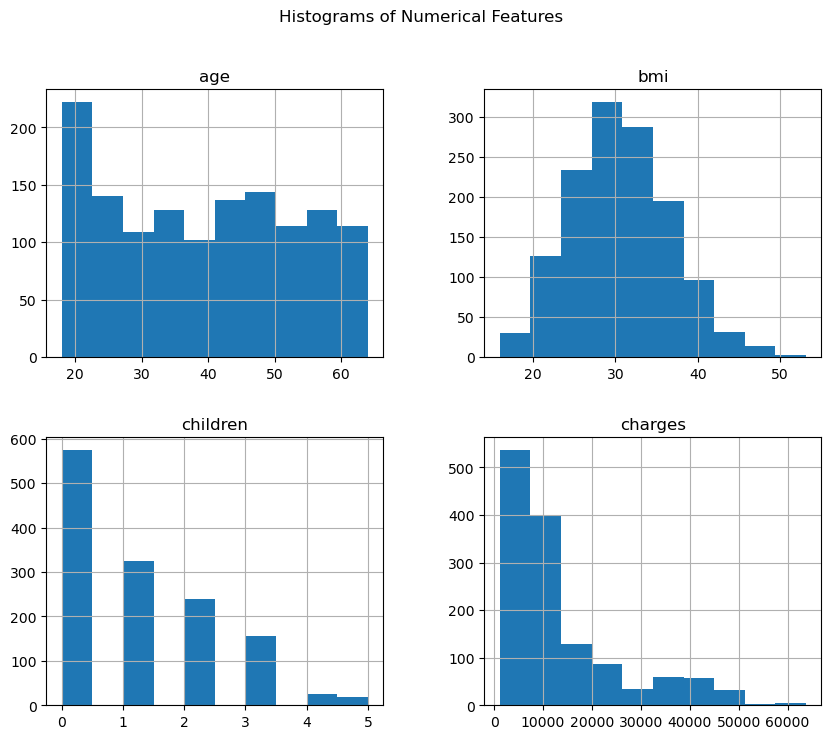

In [32]:
# Task 9: Histograms

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

df.hist(figsize=(10,8))
plt.suptitle("Histograms of Numerical Features")
plt.show()

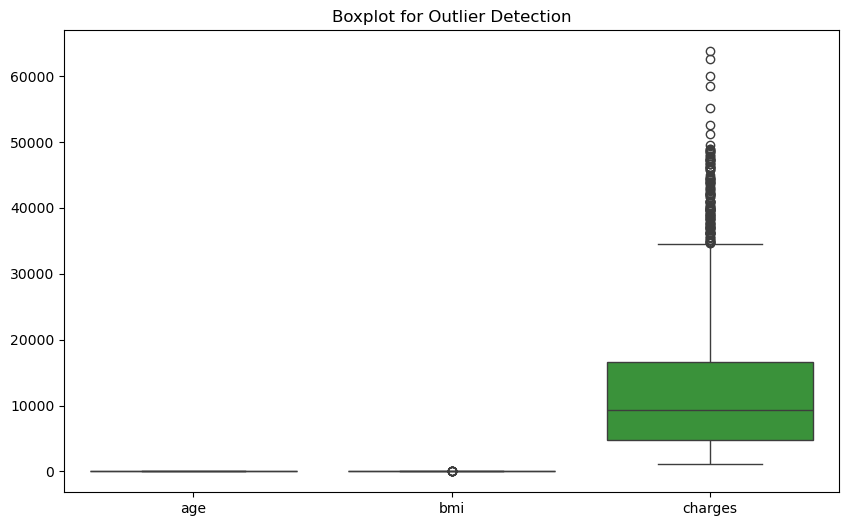

In [40]:
# Task 10: Boxplots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")

plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age', 'bmi', 'charges']])
# plt.yscale('log')   # FIX scale issue
plt.title("Boxplot for Outlier Detection")
plt.show()

In [36]:
# Task 11: Correlation Matrix

import pandas as pd

df = pd.read_csv("insurance.csv")

corr = df.corr(numeric_only=True)

print("Correlation Matrix:\n")
print(corr)

Correlation Matrix:

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000
